In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\data\processed\emi_prediction_dataset_cleaned.csv"
)

df = pd.read_csv(DATA_PATH)




df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  float64
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               404800 non-null  object 
 4   monthly_salary          404800 non-null  float64
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            404800 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [4]:
print("DATASET VERIFICATION")


print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nTotal Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

print("\nDataset is ready for EDA!")

DATASET VERIFICATION

Rows: 404,800
Columns: 27

Total Missing Values: 0
Total Duplicate Rows: 0

Dataset is ready for EDA!


In [5]:
eligibility_counts = df["emi_eligibility"].value_counts()

eligibility_percentage = (
    df["emi_eligibility"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

eligibility_summary = pd.DataFrame({
    "Count": eligibility_counts,
    "Percentage (%)": eligibility_percentage
})

print("EMI ELIGIBILITY DISTRIBUTION")
display(eligibility_summary)

EMI ELIGIBILITY DISTRIBUTION


,Count,Percentage (%)
emi_eligibility,,
Not_Eligible,312868,77.29
Eligible,74444,18.39
High_Risk,17488,4.32


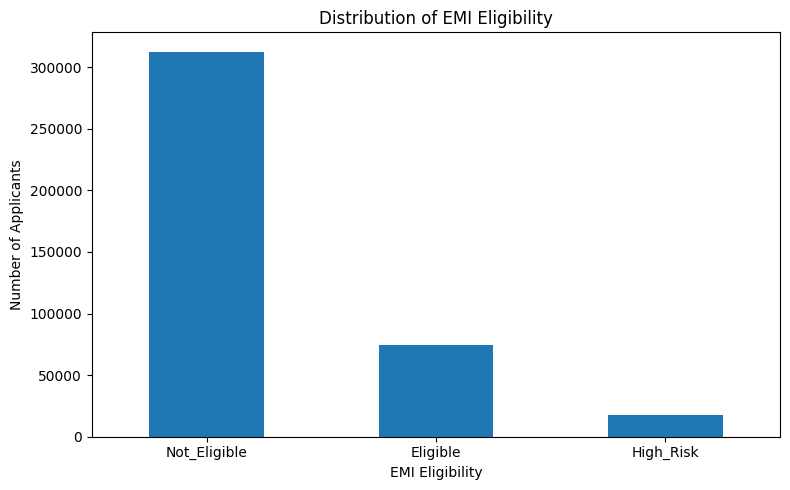

In [6]:
plt.figure(figsize=(8, 5))

df["emi_eligibility"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [7]:
class_distribution = (
    df["emi_eligibility"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Class Distribution (%):")
print(class_distribution)

largest_class = class_distribution.max()
smallest_class = class_distribution.min()

print(f"\nLargest Class: {largest_class}%")
print(f"Smallest Class: {smallest_class}%")
print(f"Difference: {largest_class - smallest_class:.2f}%")

Class Distribution (%):
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64

Largest Class: 77.29%
Smallest Class: 4.32%
Difference: 72.97%


In [8]:
print("MAXIMUM MONTHLY EMI STATISTICAL SUMMARY")

emi_summary = df["max_monthly_emi"].describe()

display(emi_summary)

MAXIMUM MONTHLY EMI STATISTICAL SUMMARY


count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

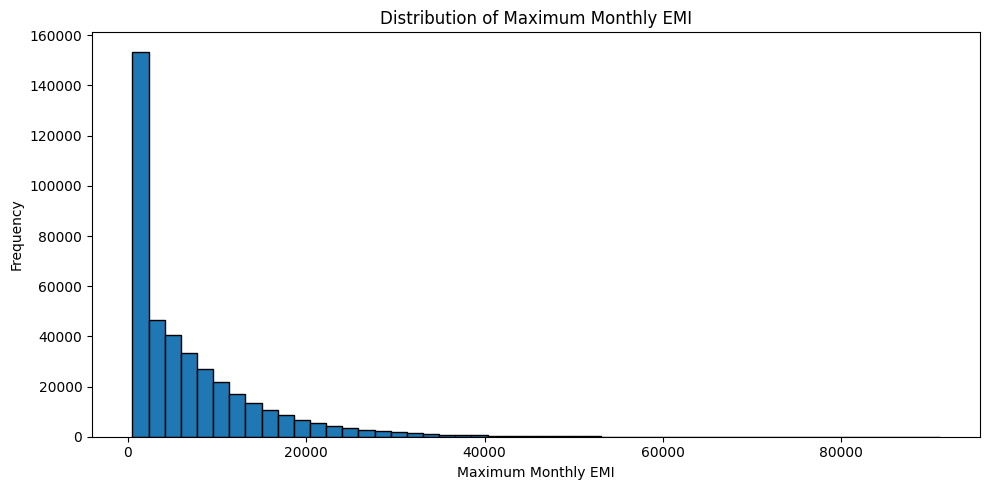

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["max_monthly_emi"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Maximum Monthly EMI")
plt.xlabel("Maximum Monthly EMI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
min_emi_count = (df["max_monthly_emi"] == 500).sum()

min_emi_percentage = (
    min_emi_count / len(df) * 100
)

print("Applicants with ₹500 maximum EMI:")
print(f"Count: {min_emi_count:,}")
print(f"Percentage: {min_emi_percentage:.2f}%")

Applicants with ₹500 maximum EMI:
Count: 106,683
Percentage: 26.35%


In [11]:
emi_500_analysis = pd.crosstab(
    df["max_monthly_emi"] == 500,
    df["emi_eligibility"],
    normalize="index"
) * 100

print("EMI Eligibility distribution by ₹500 EMI:")
display(emi_500_analysis.round(2))

EMI Eligibility distribution by ₹500 EMI:


emi_eligibility,Eligible,High_Risk,Not_Eligible
max_monthly_emi,,,
False,24.97,5.87,69.16
True,0.00,0.00,100.00


AGE STATISTICAL SUMMARY


count    404800.000000
mean         38.875860
std           9.303593
min          26.000000
25%          32.000000
50%          38.000000
75%          48.000000
max          59.000000
Name: age, dtype: float64

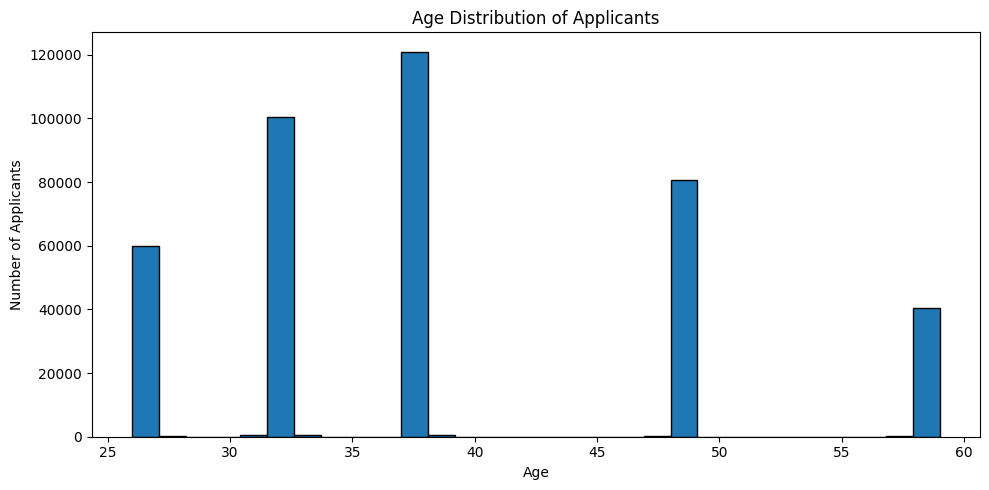

In [12]:
print("AGE STATISTICAL SUMMARY")
display(df["age"].describe())

plt.figure(figsize=(10, 5))

plt.hist(
    df["age"],
    bins=30,
    edgecolor="black"
)

plt.title("Age Distribution of Applicants")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [13]:

print("AGE STATISTICAL SUMMARY")


display(df["age"].describe())

print("\nAge Value Counts:")
print(df["age"].value_counts().sort_index())

AGE STATISTICAL SUMMARY


count    404800.000000
mean         38.875860
std           9.303593
min          26.000000
25%          32.000000
50%          38.000000
75%          48.000000
max          59.000000
Name: age, dtype: float64


Age Value Counts:
age
26.0       211
27.0     59852
28.0       230
31.0       393
32.0    100425
33.0       445
37.0       490
38.0    120509
39.0       480
47.0       297
48.0     80388
49.0       320
57.0       168
58.0     40409
59.0       183
Name: count, dtype: int64


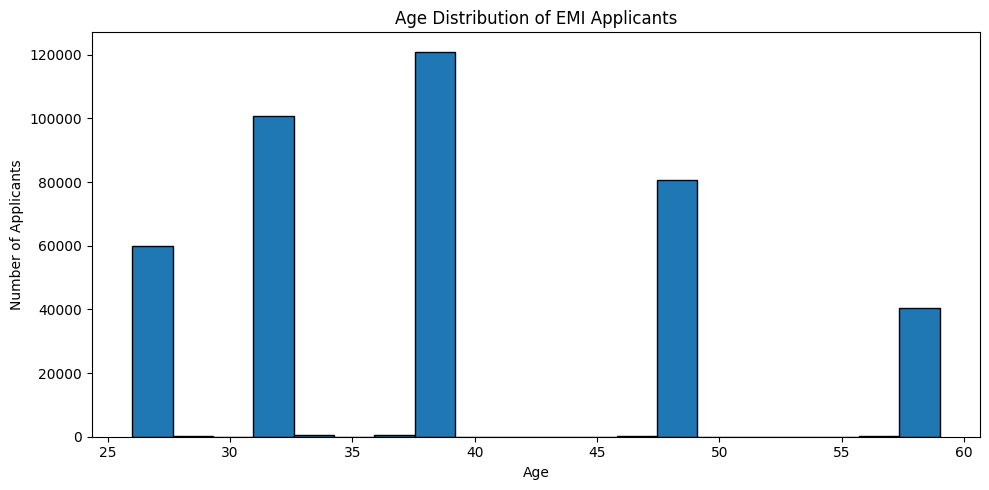

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution of EMI Applicants")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [15]:
age_eligibility = pd.crosstab(
    df["age"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(age_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
age,,,
26.0,17.06,4.27,78.67
27.0,18.93,4.42,76.65
28.0,16.96,3.91,79.13
31.0,21.37,2.80,75.83
32.0,18.22,4.33,77.45
33.0,18.20,2.70,79.10
37.0,19.39,4.90,75.71
38.0,18.24,4.22,77.54
39.0,19.58,4.38,76.04


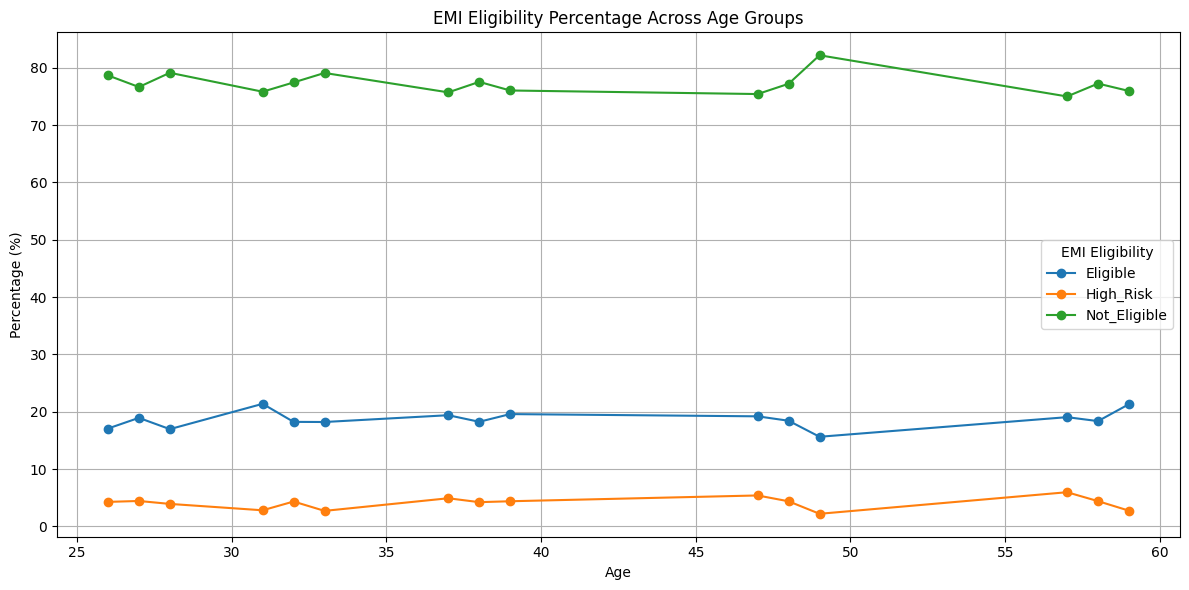

In [16]:
age_eligibility.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("EMI Eligibility Percentage Across Age Groups")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="EMI Eligibility")
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
gender_counts = df["gender"].value_counts()

gender_percentage = (
    df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

gender_summary = pd.DataFrame({
    "Count": gender_counts,
    "Percentage (%)": gender_percentage
})

display(gender_summary)

,Count,Percentage (%)
gender,,
Male,242950,60.02
Female,161850,39.98


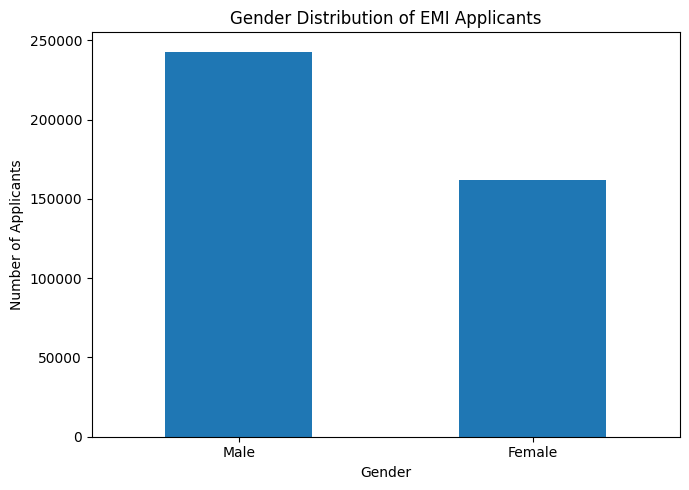

In [18]:
plt.figure(figsize=(7, 5))

df["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution of EMI Applicants")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

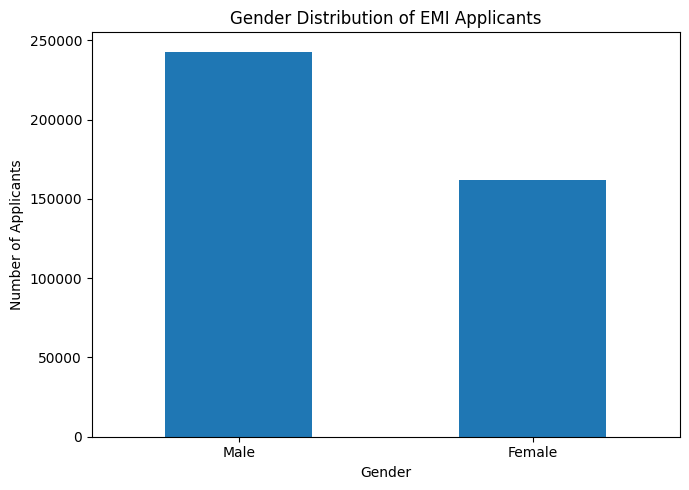

In [19]:
plt.figure(figsize=(7, 5))

df["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution of EMI Applicants")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
gender_eligibility = pd.crosstab(
    df["gender"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(gender_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
gender,,,
Female,18.39,4.32,77.29
Male,18.39,4.32,77.29


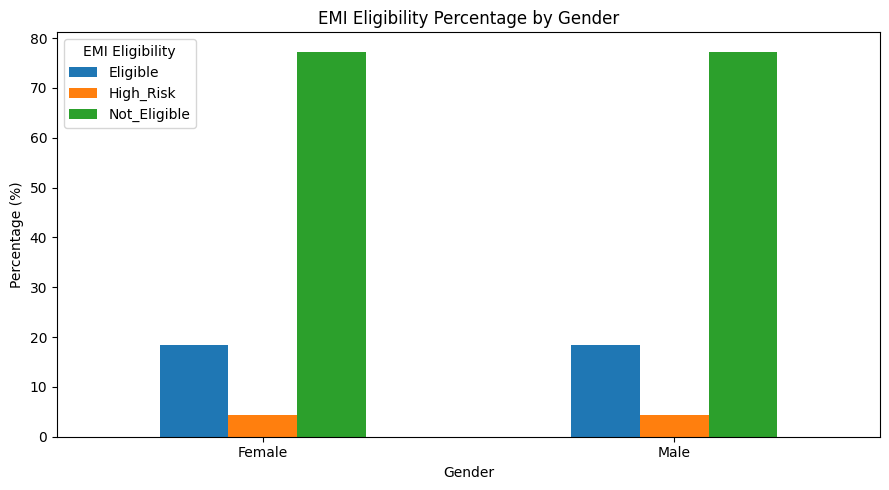

In [21]:
gender_eligibility.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("EMI Eligibility Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [22]:
marital_counts = df["marital_status"].value_counts()

marital_percentage = (
    df["marital_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

marital_summary = pd.DataFrame({
    "Count": marital_counts,
    "Percentage (%)": marital_percentage
})

display(marital_summary)

,Count,Percentage (%)
marital_status,,
Married,307837,76.05
Single,96963,23.95


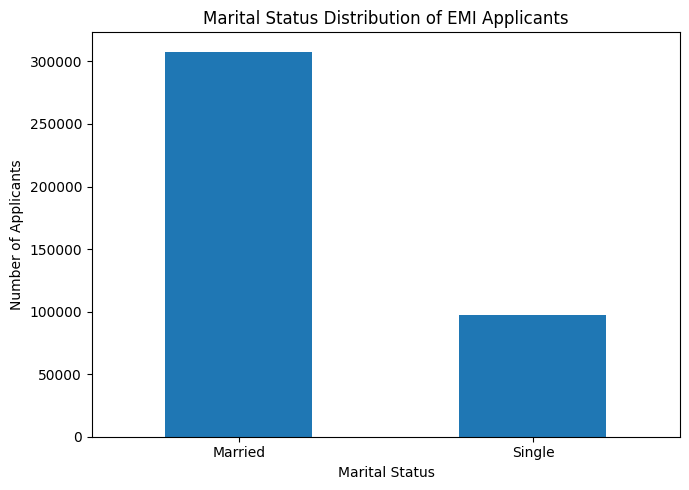

In [23]:
plt.figure(figsize=(7, 5))

df["marital_status"].value_counts().plot(
    kind="bar"
)

plt.title("Marital Status Distribution of EMI Applicants")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
marital_eligibility = pd.crosstab(
    df["marital_status"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(marital_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
marital_status,,,
Married,17.68,4.17,78.15
Single,20.65,4.78,74.57


In [25]:
education_counts = df["education"].value_counts()

education_percentage = (
    df["education"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

education_summary = pd.DataFrame({
    "Count": education_counts,
    "Percentage (%)": education_percentage
})

display(education_summary)

,Count,Percentage (%)
education,,
Graduate,183419,45.31
Post Graduate,100314,24.78
High School,60732,15.00
Professional,60335,14.90


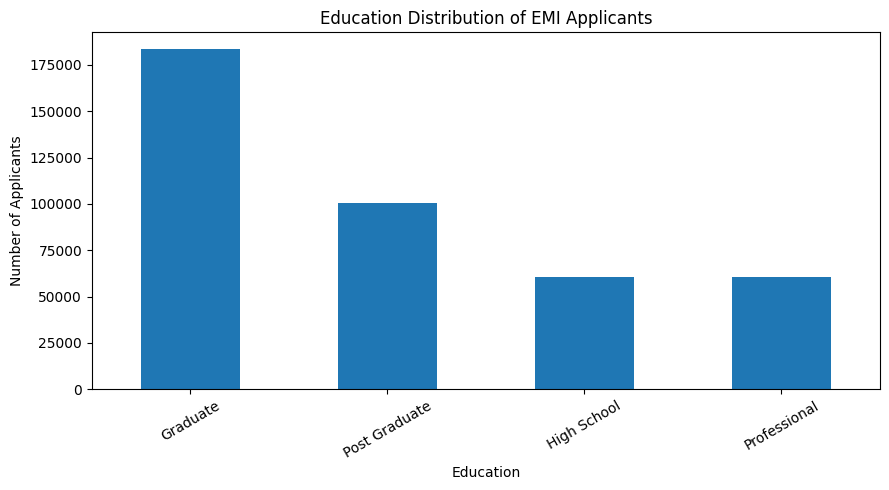

In [26]:
plt.figure(figsize=(9, 5))

df["education"].value_counts().plot(
    kind="bar"
)

plt.title("Education Distribution of EMI Applicants")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

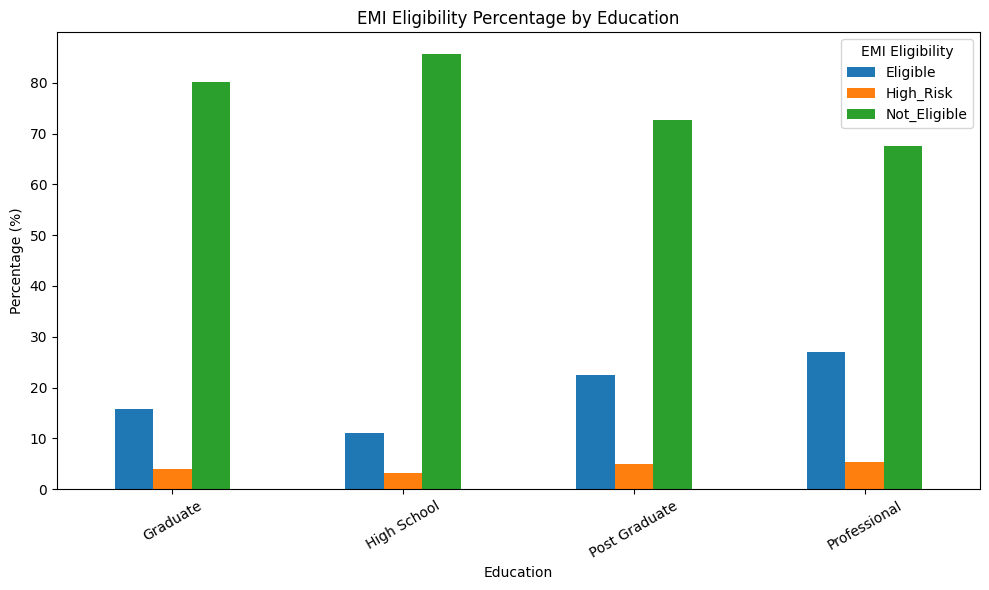

In [27]:
education_eligibility = pd.crosstab(
    df["education"],
    df["emi_eligibility"],
    normalize="index"
) * 100

education_eligibility.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("EMI Eligibility Percentage by Education")
plt.xlabel("Education")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [28]:
employment_counts = df["employment_type"].value_counts()

employment_percentage = (
    df["employment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

employment_summary = pd.DataFrame({
    "Count": employment_counts,
    "Percentage (%)": employment_percentage
})

display(employment_summary)

,Count,Percentage (%)
employment_type,,
Private,283099,69.94
Government,81167,20.05
Self-employed,40534,10.01


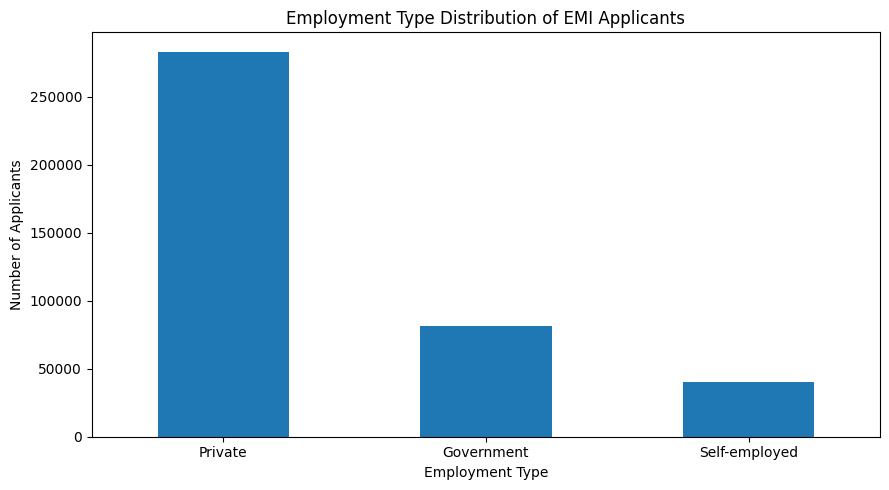

In [29]:
plt.figure(figsize=(9, 5))

df["employment_type"].value_counts().plot(
    kind="bar"
)

plt.title("Employment Type Distribution of EMI Applicants")
plt.xlabel("Employment Type")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
employment_eligibility = pd.crosstab(
    df["employment_type"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(employment_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
employment_type,,,
Government,21.40,4.61,73.99
Private,17.80,4.27,77.94
Self-employed,16.52,4.09,79.39


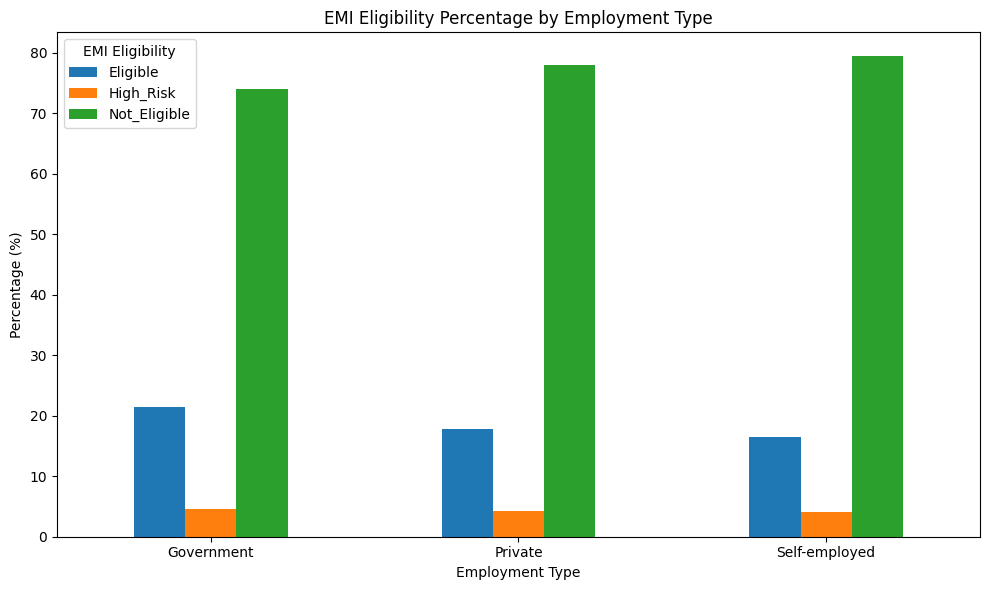

In [31]:
employment_eligibility.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("EMI Eligibility Percentage by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [32]:
salary_by_employment = (
    df.groupby("employment_type")["monthly_salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

display(salary_by_employment)

,count,mean,median,min,max
employment_type,,,,,
Government,81167,59376.57,51700.0,5000.0,499970.0
Private,283099,59540.86,51700.0,3967.0,499930.0
Self-employed,40534,59481.14,51400.0,5006.0,498176.0


In [33]:
company_counts = df["company_type"].value_counts()

company_percentage = (
    df["company_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

company_summary = pd.DataFrame({
    "Count": company_counts,
    "Percentage (%)": company_percentage
})

display(company_summary)

,Count,Percentage (%)
company_type,,
Large Indian,121139,29.93
MNC,101409,25.05
Mid-size,101301,25.02
Startup,60706,15.00
Small,20245,5.00


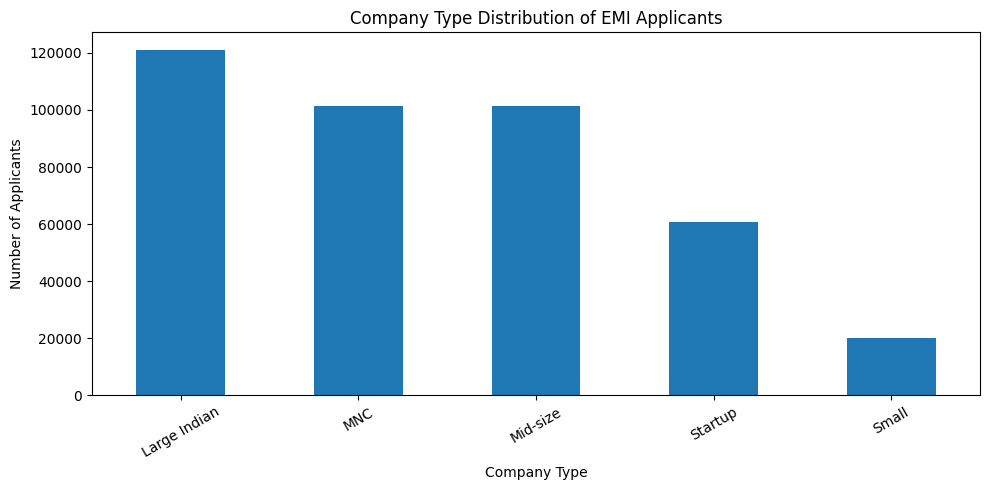

In [34]:
plt.figure(figsize=(10, 5))

df["company_type"].value_counts().plot(
    kind="bar"
)

plt.title("Company Type Distribution of EMI Applicants")
plt.xlabel("Company Type")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [35]:
company_eligibility = pd.crosstab(
    df["company_type"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(company_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
company_type,,,
Large Indian,18.54,4.35,77.11
MNC,18.38,4.35,77.27
Mid-size,18.26,4.27,77.46
Small,18.30,4.25,77.45
Startup,18.36,4.32,77.32


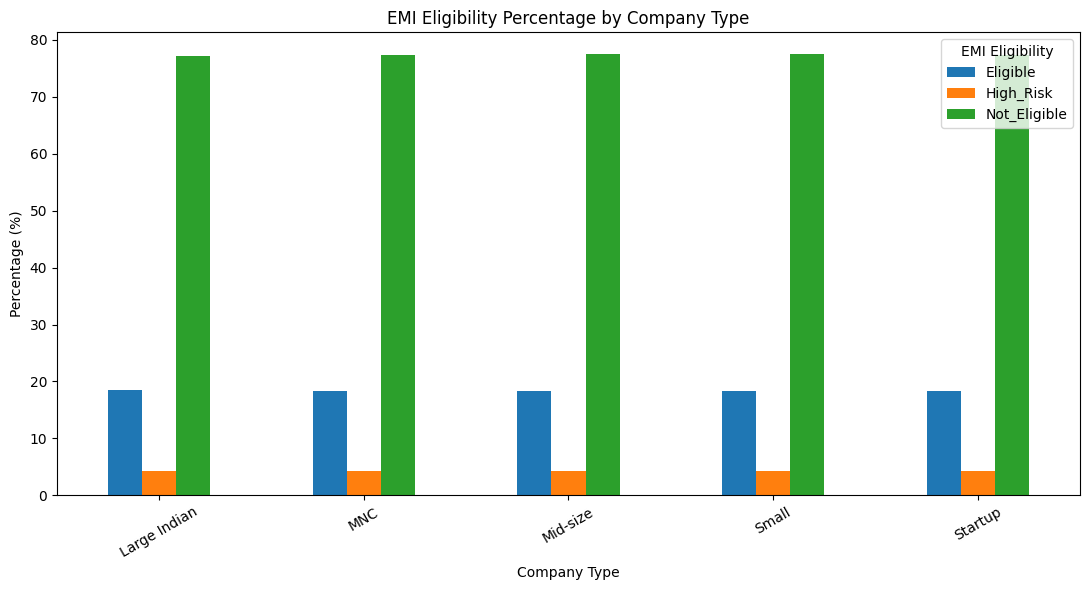

In [36]:
company_eligibility.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("EMI Eligibility Percentage by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [37]:
salary_by_company = (
    df.groupby("company_type")["monthly_salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

display(salary_by_company)

,count,mean,median,min,max
company_type,,,,,
Small,20245,59798.50,51900.0,5115.0,499264.0
Startup,60706,59478.29,51700.0,3967.0,499761.0
Mid-size,101301,59657.44,51700.0,5000.0,499930.0
MNC,101409,59465.51,51600.0,4551.0,499581.0
Large Indian,121139,59364.68,51500.0,4939.0,499970.0


In [38]:
house_counts = df["house_type"].value_counts()

house_percentage = (
    df["house_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

house_summary = pd.DataFrame({
    "Count": house_counts,
    "Percentage (%)": house_percentage
})

display(house_summary)

,Count,Percentage (%)
house_type,,
Rented,161601,39.92
Own,142307,35.15
Family,100892,24.92


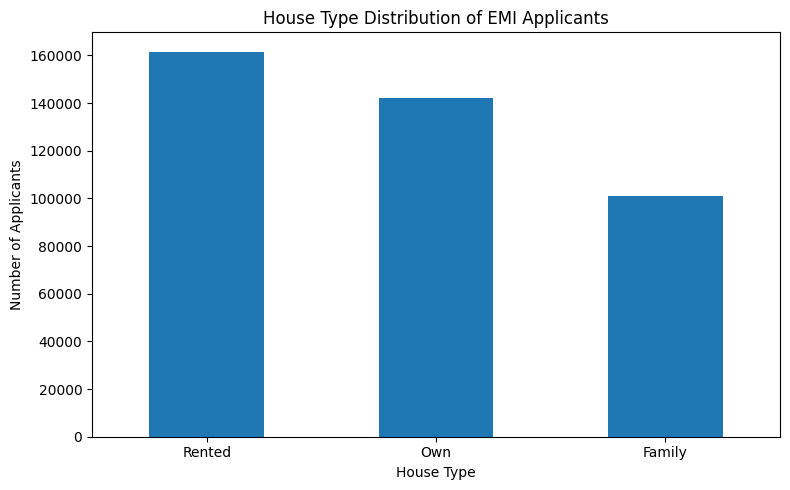

In [39]:
plt.figure(figsize=(8, 5))

df["house_type"].value_counts().plot(
    kind="bar"
)

plt.title("House Type Distribution of EMI Applicants")
plt.xlabel("House Type")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

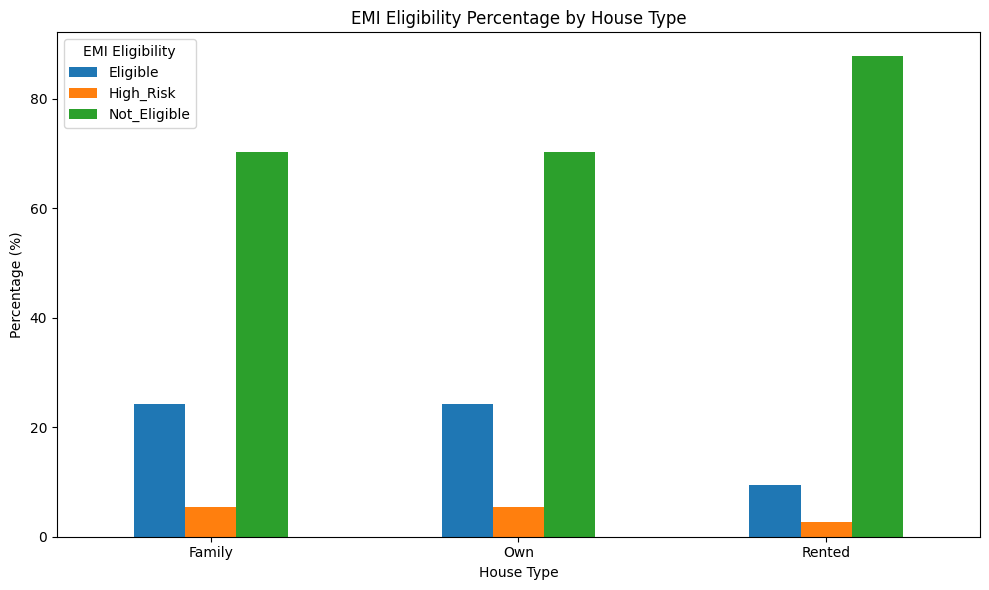

In [41]:
house_eligibility = pd.crosstab(
    df["house_type"],
    df["emi_eligibility"],
    normalize="index"
) * 100

house_eligibility.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("EMI Eligibility Percentage by House Type")
plt.xlabel("House Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [42]:
rent_by_house = (
    df.groupby("house_type")["monthly_rent"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

display(rent_by_house)

,count,mean,median,min,max
house_type,,,,,
Rented,161601,14179.79,12500.0,1800.0,80000.0
Family,100892,269.36,0.0,0.0,24990.0
Own,142307,269.20,0.0,0.0,24998.0


In [44]:
house_financial = (
    df.groupby("house_type")[
        [
            "monthly_salary",
            "monthly_rent",
            "current_emi_amount",
            "groceries_utilities",
            "other_monthly_expenses"
        ]
    ]
    .mean()
    .round(2)
)

display(house_financial)

,monthly_salary,monthly_rent,current_emi_amount,groceries_utilities,other_monthly_expenses
house_type,,,,,
Family,59450.65,269.36,4545.42,12815.79,7127.03
Own,59678.73,269.20,4577.70,12833.73,7142.83
Rented,59378.27,14179.79,4511.95,12772.97,7093.78


In [45]:
scenario_counts = df["emi_scenario"].value_counts()

scenario_percentage = (
    df["emi_scenario"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

scenario_summary = pd.DataFrame({
    "Count": scenario_counts,
    "Percentage (%)": scenario_percentage
})

display(scenario_summary)

,Count,Percentage (%)
emi_scenario,,
Home Appliances EMI,80988,20.01
Personal Loan EMI,80980,20.00
E-commerce Shopping EMI,80948,20.00
Education EMI,80942,20.00
Vehicle EMI,80942,20.00


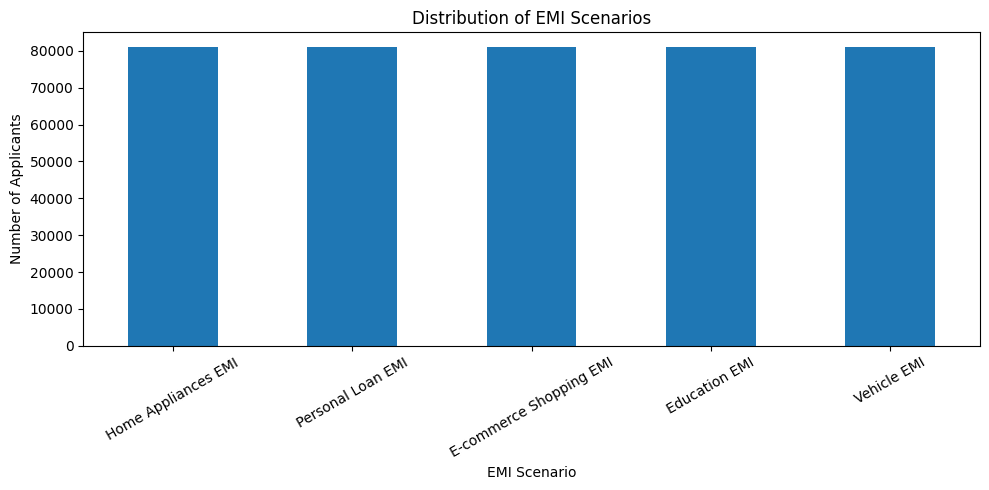

In [46]:
plt.figure(figsize=(10, 5))

df["emi_scenario"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of EMI Scenarios")
plt.xlabel("EMI Scenario")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [47]:
scenario_eligibility = pd.crosstab(
    df["emi_scenario"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(scenario_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
emi_scenario,,,
E-commerce Shopping EMI,26.32,4.95,68.74
Education EMI,17.73,4.76,77.50
Home Appliances EMI,26.00,5.19,68.81
Personal Loan EMI,11.34,3.42,85.25
Vehicle EMI,10.56,3.29,86.15


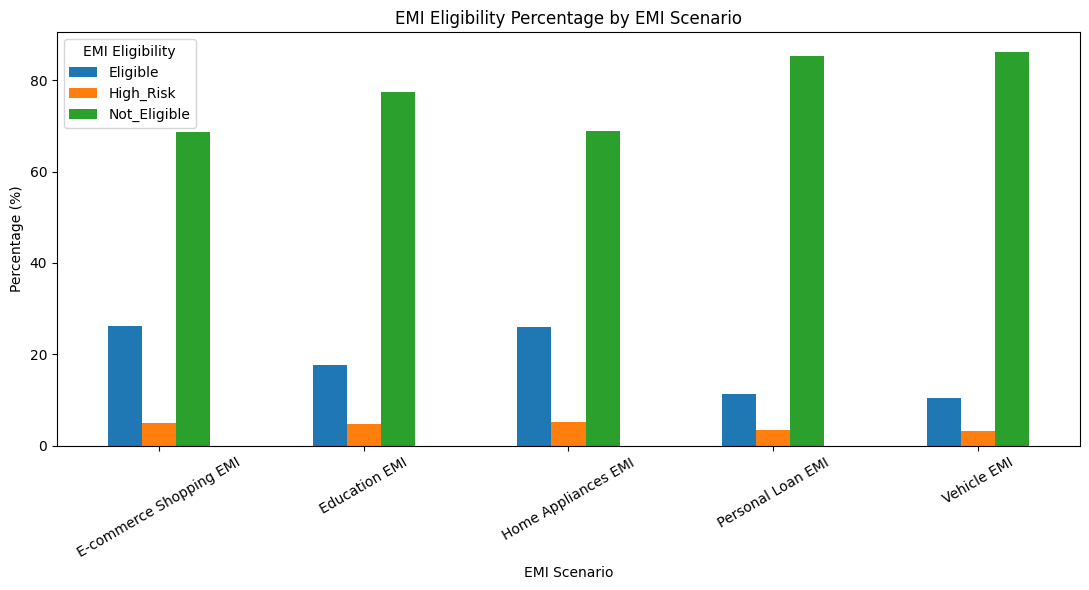

In [48]:
scenario_eligibility.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("EMI Eligibility Percentage by EMI Scenario")
plt.xlabel("EMI Scenario")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [49]:
scenario_amount = (
    df.groupby("emi_scenario")["requested_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

display(scenario_amount)

,count,mean,median,min,max
emi_scenario,,,,,
Vehicle EMI,80942,790530.65,792000.0,80000.0,1500000.0
Personal Loan EMI,80980,524362.13,525000.0,50000.0,1000000.0
Education EMI,80942,274665.18,275000.0,50000.0,500000.0
Home Appliances EMI,80988,159885.16,160000.0,20000.0,300000.0
E-commerce Shopping EMI,80948,104901.43,105000.0,10000.0,200000.0


In [50]:
scenario_tenure = (
    df.groupby("emi_scenario")["requested_tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(scenario_tenure)

,count,mean,median,min,max
emi_scenario,,,,,
E-commerce Shopping EMI,80948,13.52,14.0,3,24
Education EMI,80942,27.03,27.0,6,48
Home Appliances EMI,80988,20.99,21.0,6,36
Personal Loan EMI,80980,36.02,36.0,12,60
Vehicle EMI,80942,48.08,48.0,12,84


In [51]:
loan_counts = df["existing_loans"].value_counts()

loan_percentage = (
    df["existing_loans"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_summary = pd.DataFrame({
    "Count": loan_counts,
    "Percentage (%)": loan_percentage
})

display(loan_summary)

,Count,Percentage (%)
existing_loans,,
No,243227,60.09
Yes,161573,39.91


In [52]:
loan_eligibility = pd.crosstab(
    df["existing_loans"],
    df["emi_eligibility"],
    normalize="index"
) * 100

display(loan_eligibility.round(2))

emi_eligibility,Eligible,High_Risk,Not_Eligible
existing_loans,,,
No,25.78,5.61,68.61
Yes,7.27,2.38,90.35


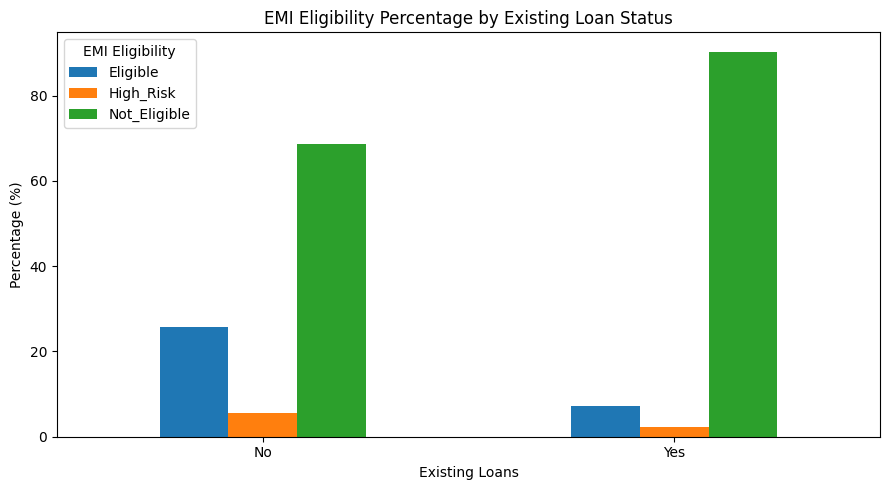

In [53]:
loan_eligibility.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("EMI Eligibility Percentage by Existing Loan Status")
plt.xlabel("Existing Loans")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

In [54]:
display(
    df["monthly_salary"].describe().round(2)
)

count    404800.00
mean      59501.94
std       43367.18
min        3967.00
25%       35400.00
50%       51700.00
75%       73000.00
max      499970.00
Name: monthly_salary, dtype: float64

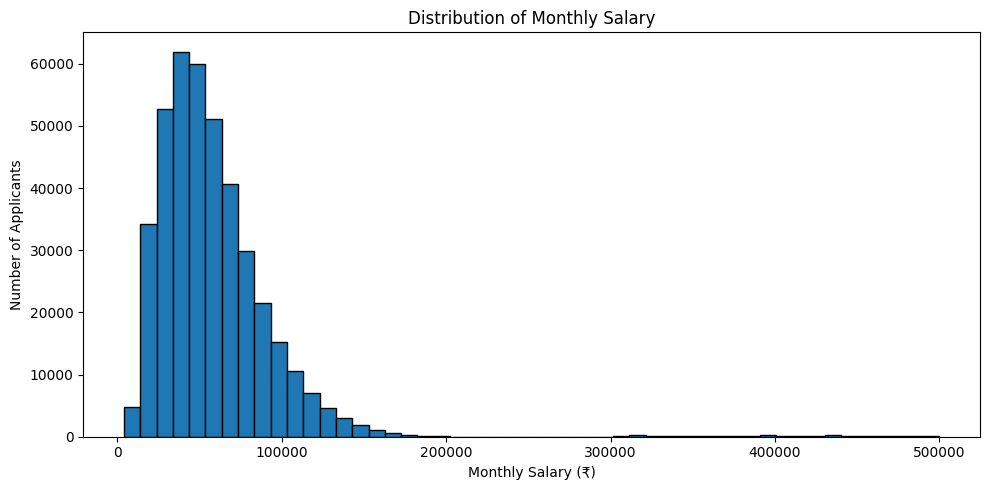

In [55]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["monthly_salary"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

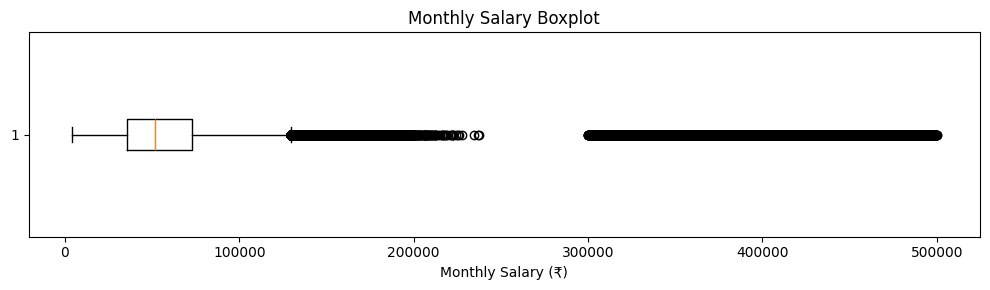

In [56]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["monthly_salary"],
    vert=False
)

plt.title("Monthly Salary Boxplot")
plt.xlabel("Monthly Salary (₹)")

plt.tight_layout()
plt.show()

In [57]:
salary_eligibility = (
    df.groupby("emi_eligibility")["monthly_salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(salary_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,78981.60,72800.0,4551.0,499761.0
High_Risk,17488,70300.78,63800.0,5028.0,495779.0
Not_Eligible,312868,54263.32,46900.0,3967.0,499970.0


<Figure size 1000x600 with 0 Axes>

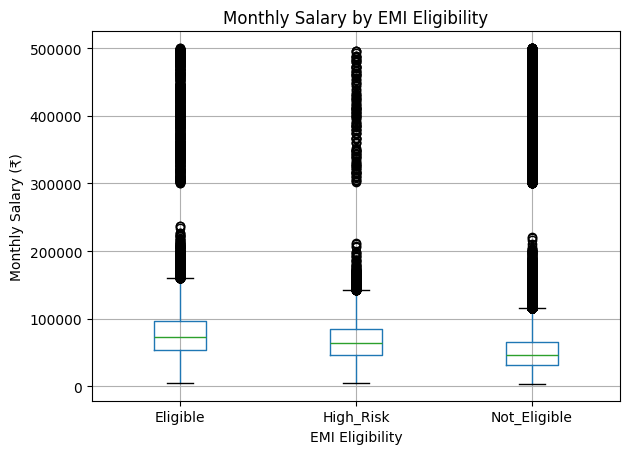

In [58]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="monthly_salary",
    by="emi_eligibility"
)

plt.title("Monthly Salary by EMI Eligibility")
plt.suptitle("")
plt.xlabel("EMI Eligibility")
plt.ylabel("Monthly Salary (₹)")

plt.tight_layout()
plt.show()

In [59]:
display(
    df["credit_score"].describe().round(2)
)

count    404800.00
mean        700.40
std          67.26
min         407.00
25%         655.00
50%         701.00
75%         746.00
max         850.00
Name: credit_score, dtype: float64

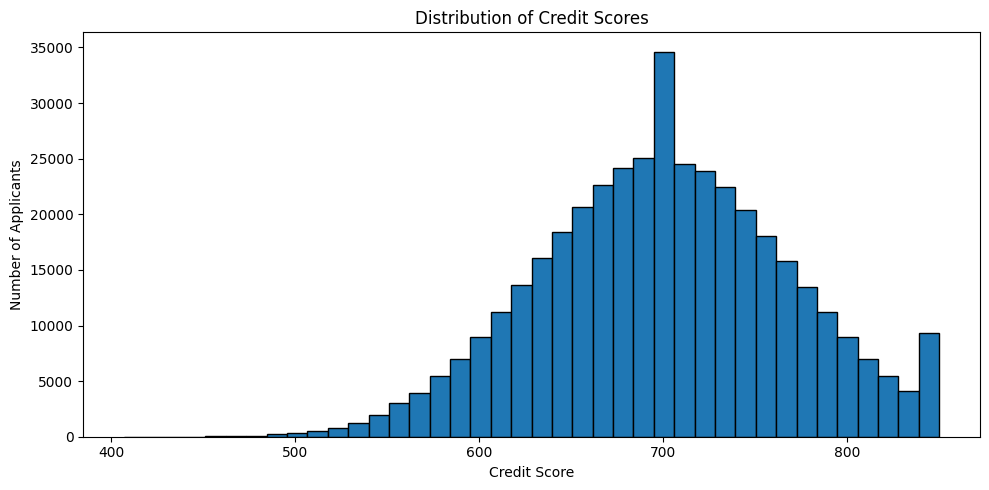

In [60]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["credit_score"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [61]:
credit_eligibility = (
    df.groupby("emi_eligibility")["credit_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(credit_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,725.17,725.0,432.0,850.0
High_Risk,17488,715.69,714.0,482.0,850.0
Not_Eligible,312868,693.65,695.0,407.0,850.0


<Figure size 1000x600 with 0 Axes>

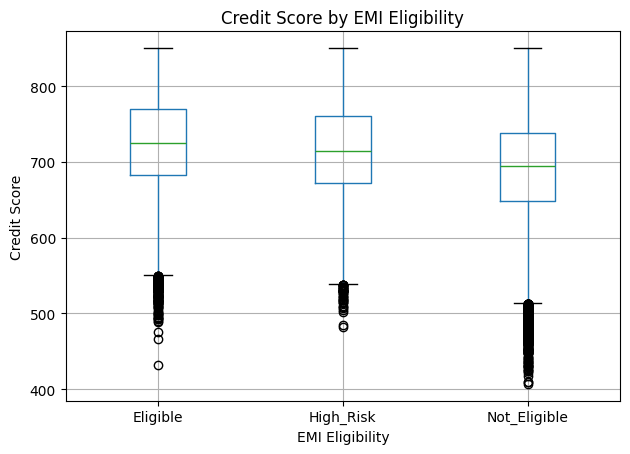

In [62]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="credit_score",
    by="emi_eligibility"
)

plt.title("Credit Score by EMI Eligibility")
plt.suptitle("")
plt.xlabel("EMI Eligibility")
plt.ylabel("Credit Score")

plt.tight_layout()
plt.show()

In [63]:
print("BANK BALANCE STATISTICAL SUMMARY")


display(
    df["bank_balance"].describe().round(2)
)

BANK BALANCE STATISTICAL SUMMARY


count     404800.00
mean      241412.96
std       182707.01
min         6100.00
25%       104900.00
50%       196000.00
75%       330000.00
max      1717300.00
Name: bank_balance, dtype: float64

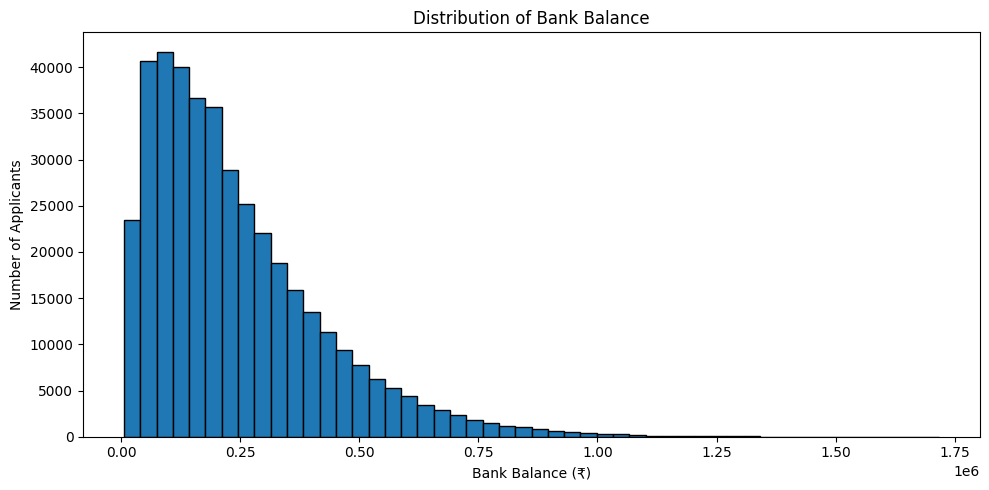

In [64]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["bank_balance"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Bank Balance")
plt.xlabel("Bank Balance (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [65]:
bank_eligibility = (
    df.groupby("emi_eligibility")["bank_balance"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(bank_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,338517.53,295100.0,10700.0,1717300.0
High_Risk,17488,293574.89,253200.0,9500.0,1500500.0
Not_Eligible,312868,215392.21,176700.0,6100.0,1532400.0


In [66]:
display(
    df["emergency_fund"].describe().round(2)
)

count    404800.00
mean      96636.81
std       81154.85
min        1400.00
25%       38600.00
50%       74000.00
75%      130200.00
max      891500.00
Name: emergency_fund, dtype: float64

In [67]:
emergency_eligibility = (
    df.groupby("emi_eligibility")["emergency_fund"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(emergency_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,135511.70,110800.0,2300.0,890600.0
High_Risk,17488,118226.32,95200.0,3100.0,724000.0
Not_Eligible,312868,86180.14,66800.0,1400.0,891500.0


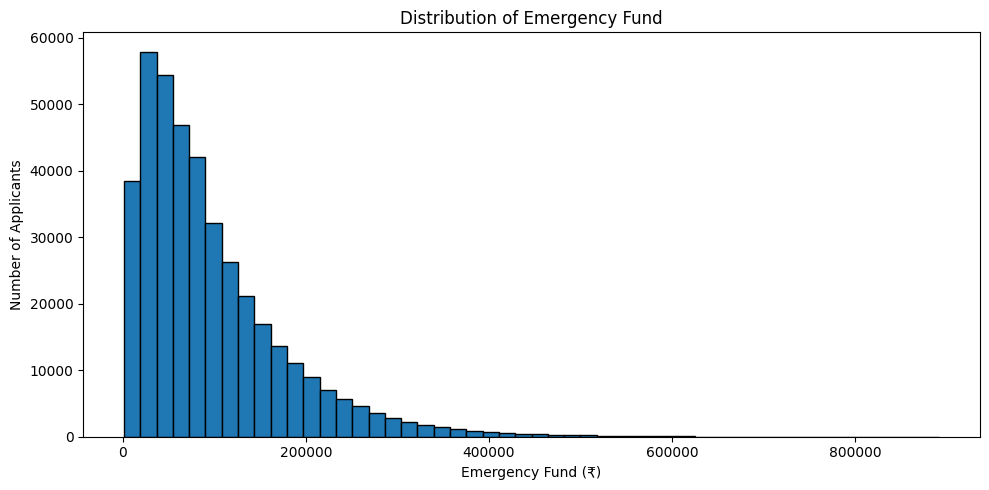

In [68]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["emergency_fund"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Emergency Fund")
plt.xlabel("Emergency Fund (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [69]:
current_emi_summary = (
    df.groupby("emi_eligibility")["current_emi_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(current_emi_summary)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,2405.85,0.0,0.0,54300.0
High_Risk,17488,3088.11,0.0,0.0,50900.0
Not_Eligible,312868,5133.36,0.0,0.0,56300.0


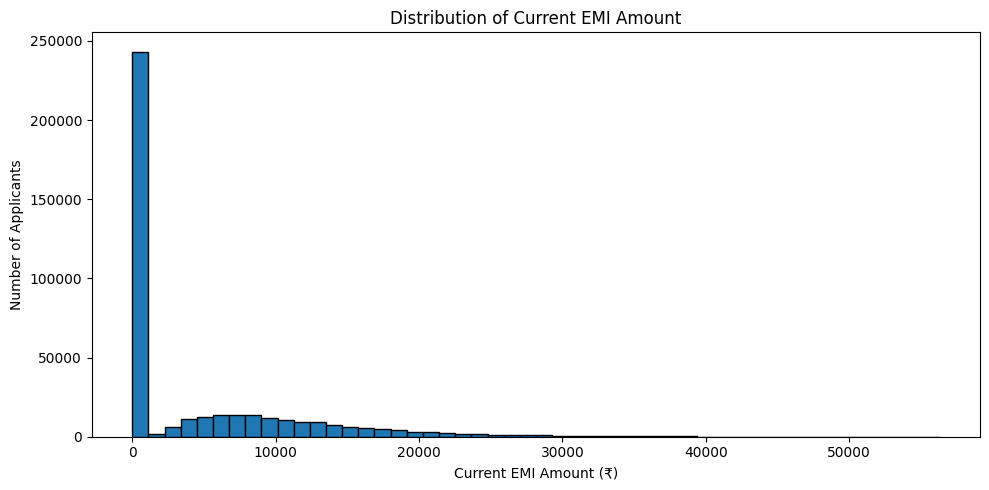

In [70]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["current_emi_amount"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Current EMI Amount")
plt.xlabel("Current EMI Amount (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [71]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount"
]

df["total_monthly_expenses"] = df[expense_columns].sum(axis=1)

print("Total monthly expenses calculated.")

display(
    df["total_monthly_expenses"]
    .describe()
    .round(2)
)

Total monthly expenses calculated.


count    404800.00
mean      44668.56
std       23072.51
min        3600.00
25%       28000.00
50%       40600.00
75%       56800.00
max      247800.00
Name: total_monthly_expenses, dtype: float64

In [72]:
expense_eligibility = (
    df.groupby("emi_eligibility")["total_monthly_expenses"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(expense_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,44915.96,41100.0,4300.0,207500.0
High_Risk,17488,42750.30,38700.0,4100.0,170000.0
Not_Eligible,312868,44716.91,40600.0,3600.0,247800.0


In [80]:
df["disposable_income"] = (
    df["monthly_salary"]
    - df["total_monthly_expenses"]
)

display(
    df["disposable_income"]
    .describe()
    .round(2)
)

count    404800.00
mean      14833.38
std       37607.52
min     -161883.00
25%         400.00
50%       10600.00
75%       22400.00
max      485540.00
Name: disposable_income, dtype: float64

In [81]:
disposable_eligibility = (
    df.groupby("emi_eligibility")["disposable_income"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(disposable_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,34065.64,28900.0,-151618.0,484077.0
High_Risk,17488,27550.48,22700.0,-117913.0,477037.0
Not_Eligible,312868,9546.41,6500.0,-161883.0,485540.0


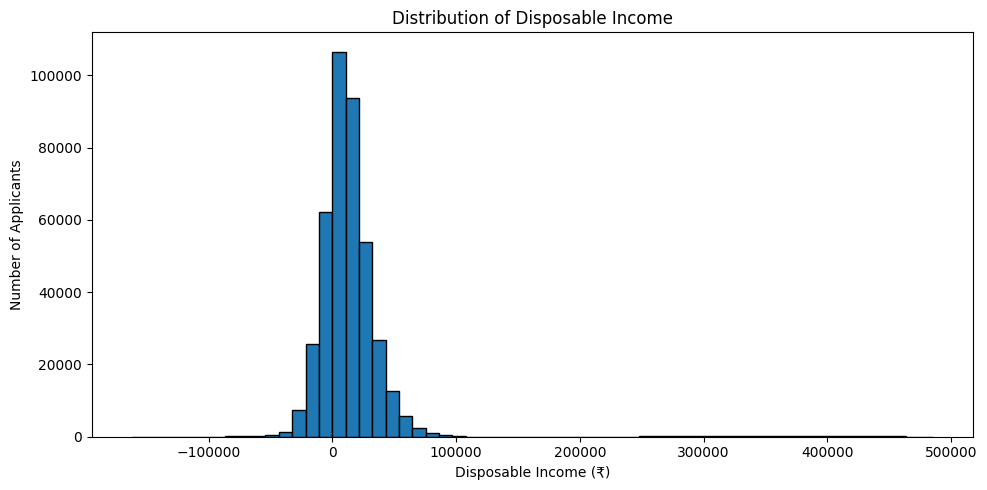

In [82]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["disposable_income"],
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Disposable Income")
plt.xlabel("Disposable Income (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [83]:
requested_amount_summary = (
    df.groupby("emi_eligibility")["requested_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(requested_amount_summary)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,155361.20,111000.0,10000.0,1499000.0
High_Risk,17488,261358.25,185000.0,10000.0,1499000.0
Not_Eligible,312868,428250.65,288000.0,10000.0,1500000.0


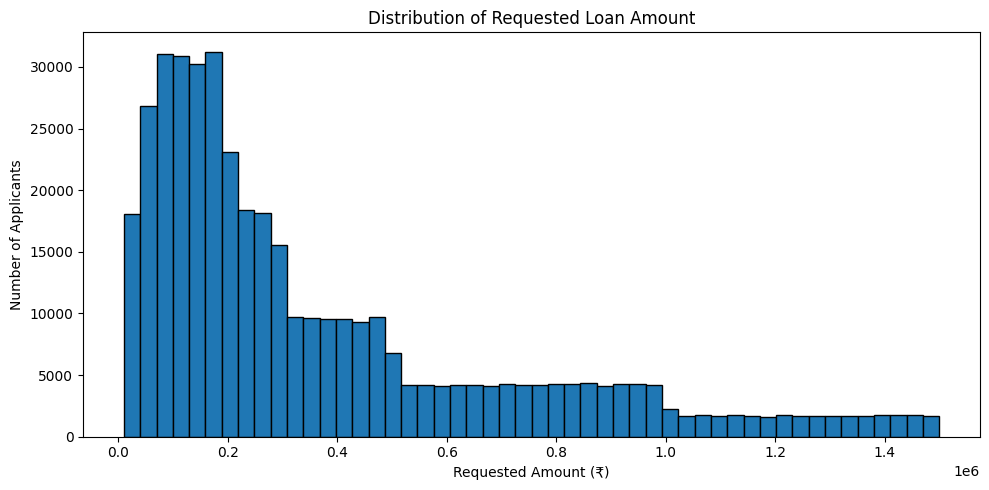

In [84]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["requested_amount"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Requested Loan Amount")
plt.xlabel("Requested Amount (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [85]:
tenure_summary = (
    df.groupby("emi_eligibility")["requested_tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(tenure_summary)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,29.65,25.0,3,84
High_Risk,17488,30.24,26.0,3,84
Not_Eligible,312868,28.94,24.0,3,84


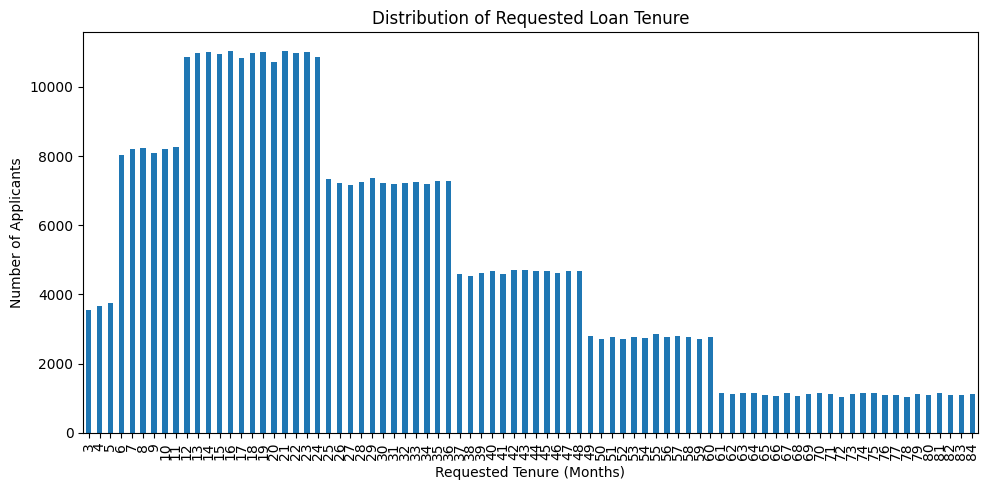

In [86]:
plt.figure(figsize=(10, 5))

df["requested_tenure"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Requested Loan Tenure")
plt.xlabel("Requested Tenure (Months)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [87]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount"
]

expense_summary = df[expense_columns].describe().T.round(2)

display(expense_summary)

,count,mean,std,min,25%,50%,75%,max
monthly_rent,404800.0,5822.51,8635.86,0.0,0.0,0.0,10700.0,80000.0
school_fees,404800.0,4624.58,5061.07,0.0,0.0,3000.0,9000.0,15000.0
college_fees,404800.0,4066.25,7319.34,0.0,0.0,0.0,6500.0,25000.0
travel_expenses,404800.0,5687.50,3392.67,600.0,3200.0,4900.0,7400.0,30300.0
groceries_utilities,404800.0,12805.00,6993.85,1800.0,7700.0,11400.0,16400.0,71200.0
other_monthly_expenses,404800.0,7119.31,4510.45,600.0,3800.0,6000.0,9300.0,42900.0
current_emi_amount,404800.0,4543.41,7034.90,0.0,0.0,0.0,8000.0,56300.0


In [88]:
average_expenses = (
    df[expense_columns]
    .mean()
    .sort_values(ascending=False)
)

display(
    average_expenses.round(2)
)

groceries_utilities       12805.00
other_monthly_expenses     7119.31
monthly_rent               5822.51
travel_expenses            5687.50
school_fees                4624.58
current_emi_amount         4543.41
college_fees               4066.25
dtype: float64

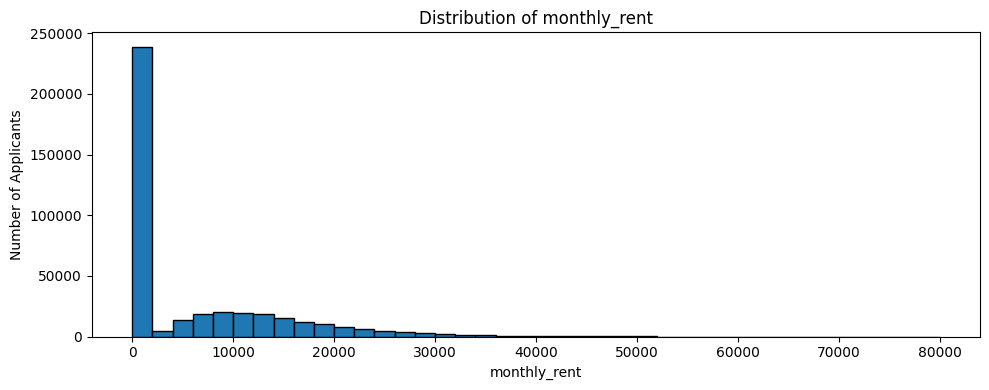

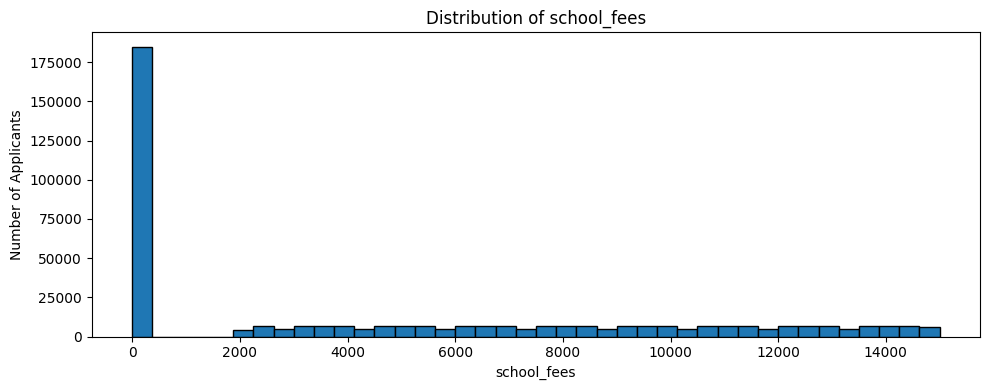

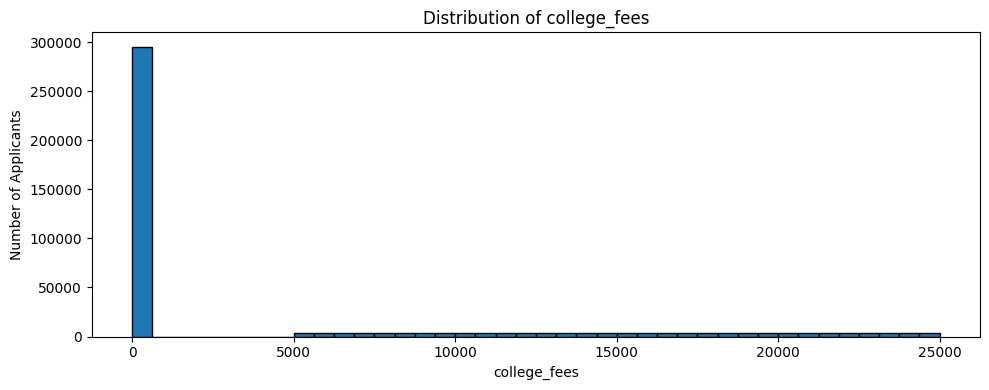

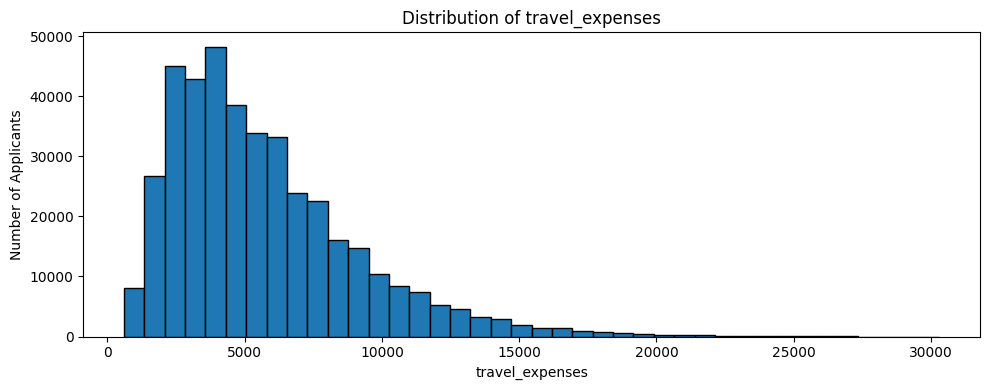

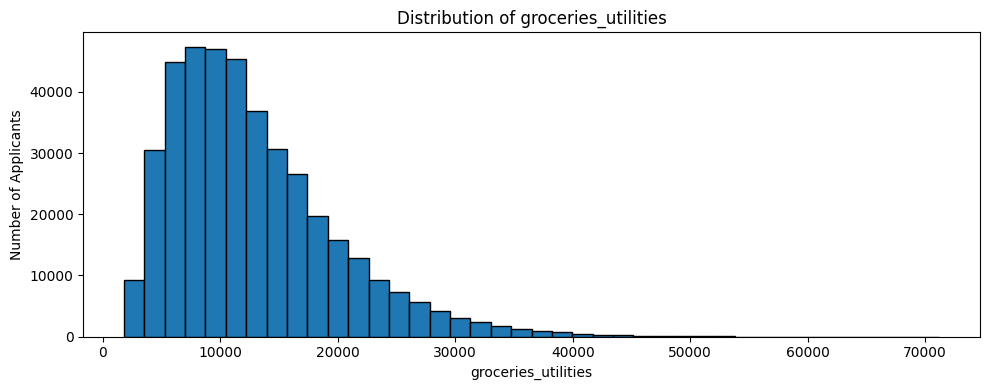

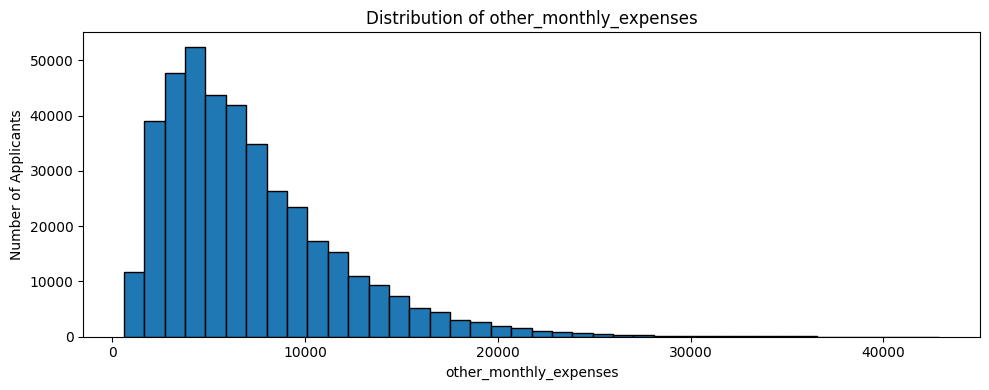

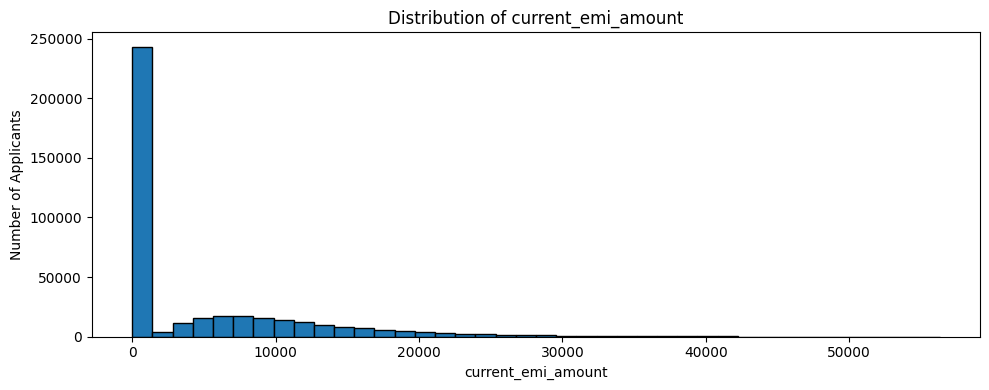

In [89]:
for col in expense_columns:

    plt.figure(figsize=(10, 4))

    plt.hist(
        df[col],
        bins=40,
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Applicants")

    plt.tight_layout()
    plt.show()

In [90]:
df["total_monthly_expenses"] = df[expense_columns].sum(axis=1)

print("Total Monthly Expenses Summary:")

display(
    df["total_monthly_expenses"]
    .describe()
    .round(2)
)

Total Monthly Expenses Summary:


count    404800.00
mean      44668.56
std       23072.51
min        3600.00
25%       28000.00
50%       40600.00
75%       56800.00
max      247800.00
Name: total_monthly_expenses, dtype: float64

In [91]:
expense_eligibility = (
    df.groupby("emi_eligibility")["total_monthly_expenses"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(expense_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,44915.96,41100.0,4300.0,207500.0
High_Risk,17488,42750.30,38700.0,4100.0,170000.0
Not_Eligible,312868,44716.91,40600.0,3600.0,247800.0


<Figure size 1000x600 with 0 Axes>

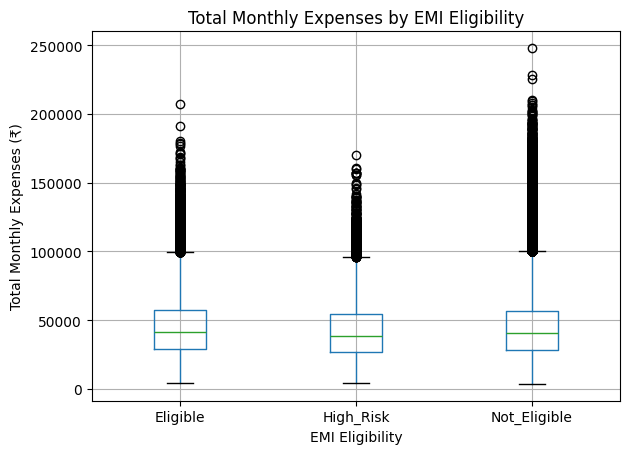

In [92]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="total_monthly_expenses",
    by="emi_eligibility"
)

plt.title("Total Monthly Expenses by EMI Eligibility")
plt.suptitle("")
plt.xlabel("EMI Eligibility")
plt.ylabel("Total Monthly Expenses (₹)")

plt.tight_layout()
plt.show()

In [93]:
df["disposable_income"] = (
    df["monthly_salary"]
    - df["total_monthly_expenses"]
)

display(
    df["disposable_income"]
    .describe()
    .round(2)
)

count    404800.00
mean      14833.38
std       37607.52
min     -161883.00
25%         400.00
50%       10600.00
75%       22400.00
max      485540.00
Name: disposable_income, dtype: float64

In [94]:
disposable_eligibility = (
    df.groupby("emi_eligibility")["disposable_income"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(disposable_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,34065.64,28900.0,-151618.0,484077.0
High_Risk,17488,27550.48,22700.0,-117913.0,477037.0
Not_Eligible,312868,9546.41,6500.0,-161883.0,485540.0


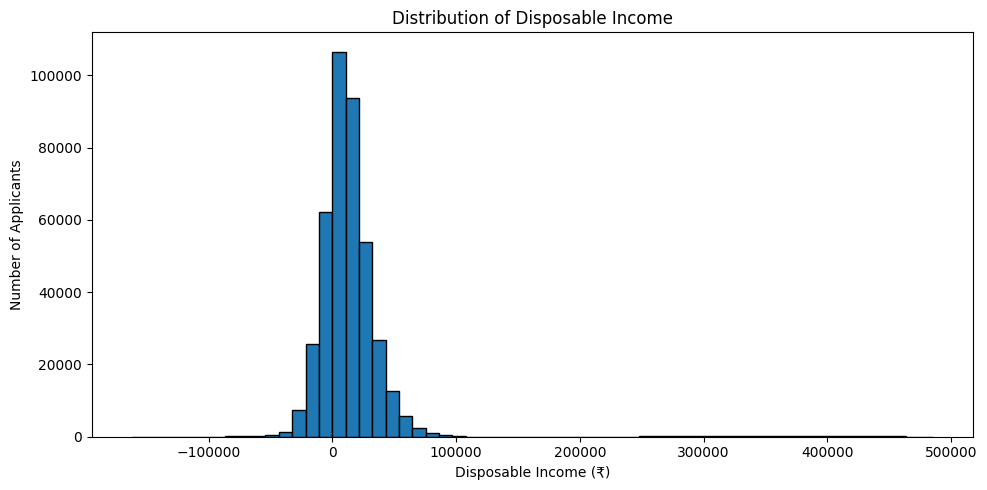

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["disposable_income"],
    bins=60,
    edgecolor="black"
)

plt.title("Distribution of Disposable Income")
plt.xlabel("Disposable Income (₹)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

In [96]:
df["expense_to_income_ratio"] = (
    df["total_monthly_expenses"]
    / df["monthly_salary"]
)

display(
    df["expense_to_income_ratio"]
    .describe()
    .round(3)
)

count    404800.000
mean          0.868
std           0.637
min           0.011
25%           0.608
50%           0.780
75%           0.991
max          31.292
Name: expense_to_income_ratio, dtype: float64

In [97]:
df["current_emi_to_income_ratio"] = (
    df["current_emi_amount"]
    / df["monthly_salary"]
)

display(
    df["current_emi_to_income_ratio"]
    .describe()
    .round(3)
)

count    404800.000
mean          0.084
std           0.142
min           0.000
25%           0.000
50%           0.000
75%           0.175
max           7.704
Name: current_emi_to_income_ratio, dtype: float64

In [98]:
ratio_analysis = (
    df.groupby("emi_eligibility")[
        [
            "expense_to_income_ratio",
            "current_emi_to_income_ratio"
        ]
    ]
    .agg(["mean", "median"])
    .round(3)
)

display(ratio_analysis)

expense_to_income_ratio        current_emi_to_income_ratio  \
                                   mean median                        mean   
emi_eligibility                                                              
Eligible                          0.620  0.571                       0.031   
High_Risk                         0.655  0.621                       0.043   
Not_Eligible                      0.939  0.857                       0.098   

                        
                median  
emi_eligibility         
Eligible           0.0  
High_Risk          0.0  
Not_Eligible       0.0

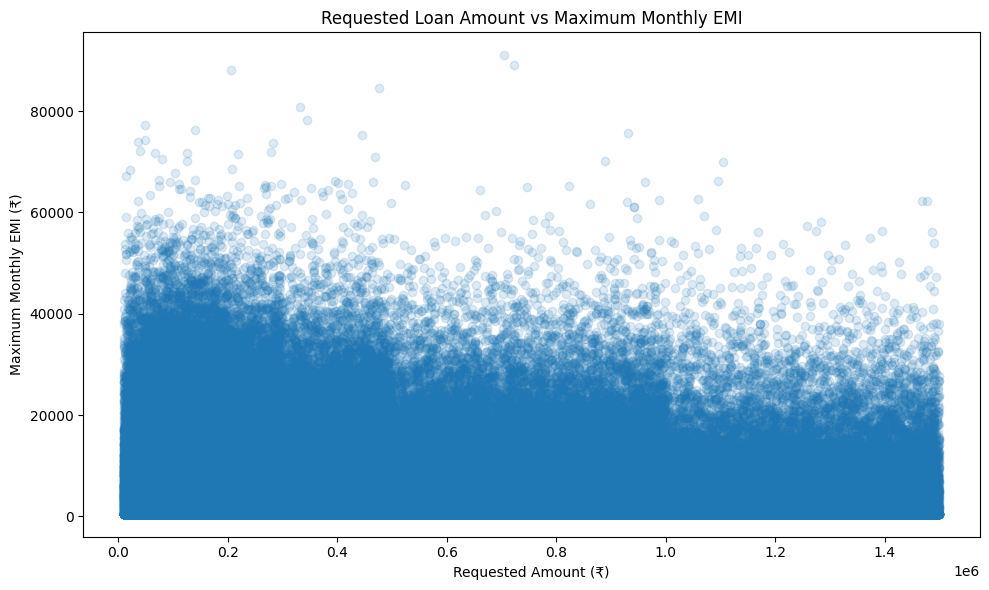

In [99]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["requested_amount"],
    df["max_monthly_emi"],
    alpha=0.15
)

plt.title("Requested Loan Amount vs Maximum Monthly EMI")
plt.xlabel("Requested Amount (₹)")
plt.ylabel("Maximum Monthly EMI (₹)")

plt.tight_layout()
plt.show()

In [100]:
requested_eligibility = (
    df.groupby("emi_eligibility")["requested_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(requested_eligibility)

,count,mean,median,min,max
emi_eligibility,,,,,
Eligible,74444,155361.20,111000.0,10000.0,1499000.0
High_Risk,17488,261358.25,185000.0,10000.0,1499000.0
Not_Eligible,312868,428250.65,288000.0,10000.0,1500000.0


In [101]:
numeric_features = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "max_monthly_emi",
    "total_monthly_expenses",
    "disposable_income",
    "expense_to_income_ratio",
    "current_emi_to_income_ratio"
]

correlation_matrix = df[numeric_features].corr()

display(correlation_matrix.round(3))

,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,...,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,max_monthly_emi,total_monthly_expenses,disposable_income,expense_to_income_ratio,current_emi_to_income_ratio
age,1.000,-0.001,0.480,0.000,0.209,0.209,0.062,0.037,-0.002,-0.002,...,0.084,-0.002,-0.002,0.001,0.000,-0.001,0.024,-0.016,0.020,-0.001
monthly_salary,-0.001,1.000,-0.000,0.208,-0.001,-0.001,-0.003,-0.002,0.542,0.594,...,0.089,0.424,0.384,-0.002,-0.000,0.379,0.499,0.847,-0.252,-0.070
years_of_employment,0.480,-0.000,1.000,0.000,0.102,0.102,0.031,0.018,-0.001,-0.000,...,0.154,-0.002,-0.001,0.001,-0.001,0.029,0.012,-0.008,0.010,0.000
monthly_rent,0.000,0.208,0.000,1.000,-0.002,-0.002,-0.004,0.001,0.273,0.296,...,0.044,0.208,0.188,-0.001,0.001,-0.171,0.584,-0.119,0.149,0.004
family_size,0.209,-0.001,0.102,-0.002,1.000,1.000,0.175,0.107,-0.001,-0.002,...,0.026,-0.002,-0.003,0.001,-0.002,-0.062,0.070,-0.044,0.059,-0.003
dependents,0.209,-0.001,0.102,-0.002,1.000,1.000,0.175,0.107,-0.001,-0.002,...,0.026,-0.002,-0.003,0.001,-0.002,-0.062,0.070,-0.044,0.059,-0.003
school_fees,0.062,-0.003,0.031,-0.004,0.175,0.175,1.000,0.055,0.001,-0.000,...,0.006,-0.001,-0.002,0.001,0.000,-0.215,0.235,-0.148,0.206,0.002
college_fees,0.037,-0.002,0.018,0.001,0.107,0.107,0.055,1.000,-0.002,-0.003,...,0.004,-0.003,-0.002,0.004,-0.001,-0.259,0.329,-0.204,0.282,0.000
travel_expenses,-0.002,0.542,-0.001,0.273,-0.001,-0.001,0.001,-0.002,1.000,0.772,...,0.118,0.552,0.499,-0.001,-0.001,0.441,0.695,0.199,-0.069,0.015
groceries_utilities,-0.002,0.594,-0.000,0.296,-0.002,-0.002,-0.000,-0.003,0.772,1.000,...,0.129,0.604,0.546,0.000,-0.000,0.485,0.759,0.219,-0.077,0.017


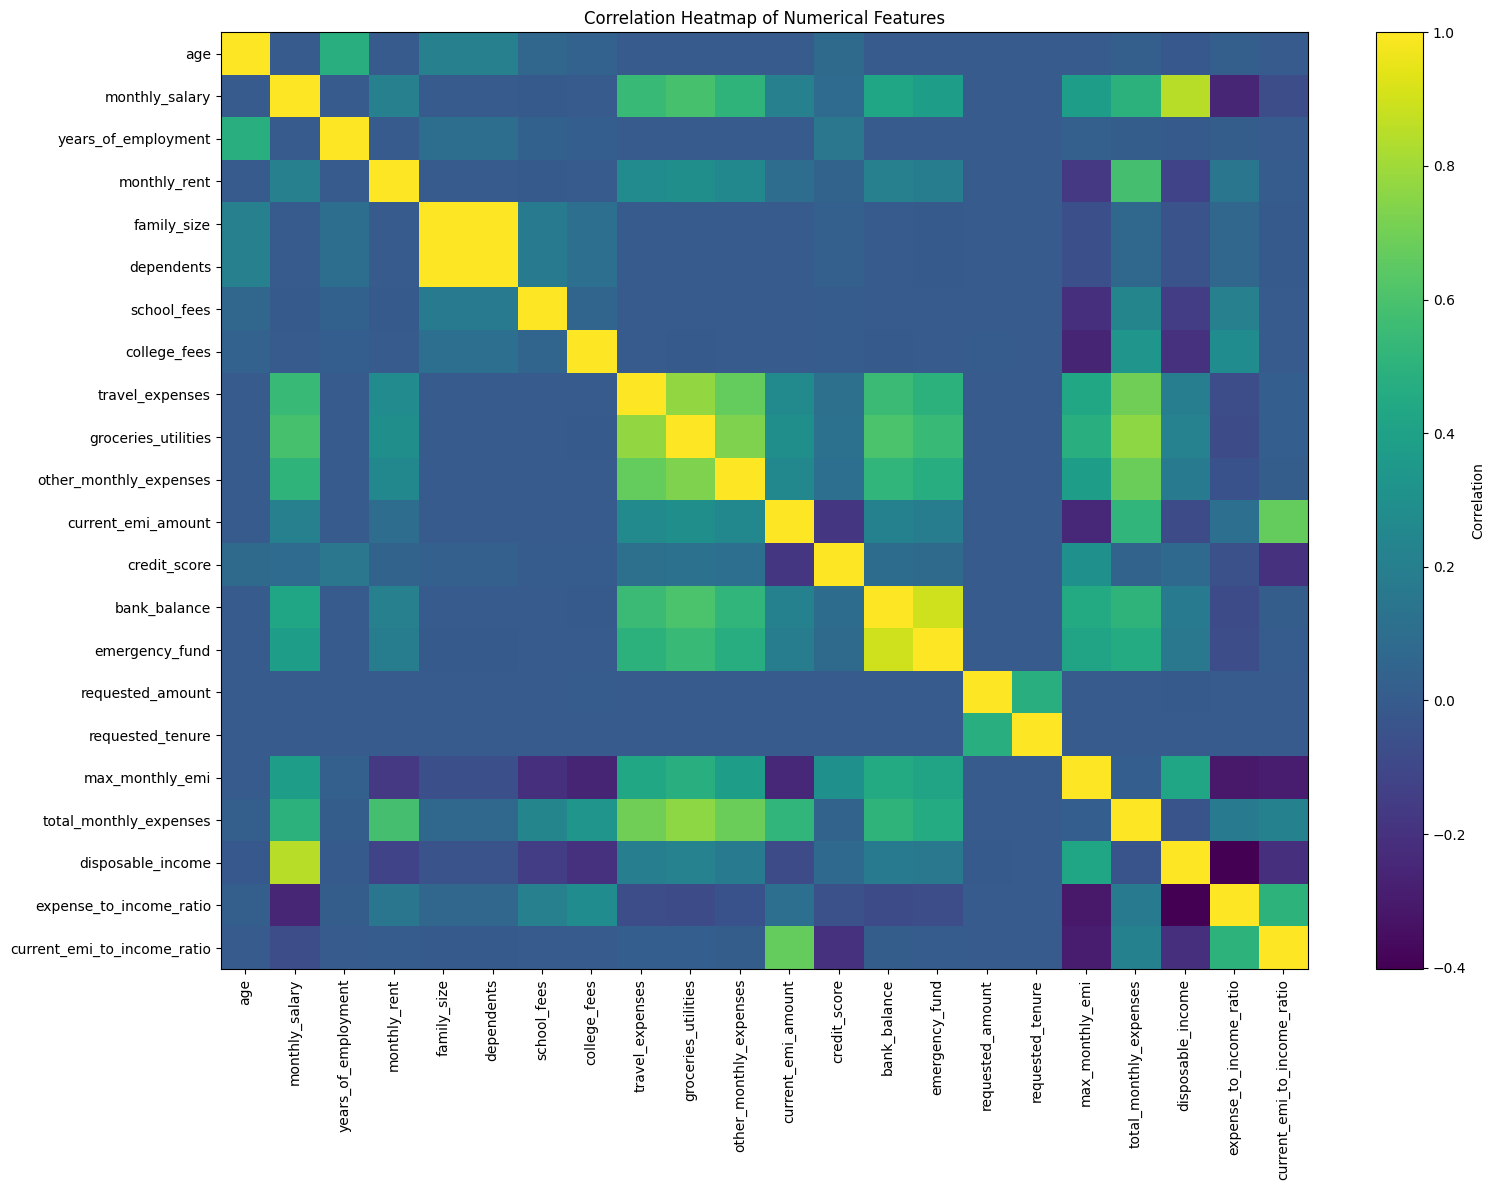

In [102]:
plt.figure(figsize=(16, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [103]:
emi_correlations = (
    correlation_matrix["max_monthly_emi"]
    .drop("max_monthly_emi")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Maximum Monthly EMI:")

display(
    emi_correlations.round(3)
)

Correlation with Maximum Monthly EMI:


groceries_utilities            0.485
bank_balance                   0.457
travel_expenses                0.441
disposable_income              0.426
emergency_fund                 0.414
other_monthly_expenses         0.382
monthly_salary                 0.379
expense_to_income_ratio       -0.308
credit_score                   0.299
current_emi_to_income_ratio   -0.289
college_fees                  -0.259
current_emi_amount            -0.242
school_fees                   -0.215
monthly_rent                  -0.171
family_size                   -0.062
dependents                    -0.062
years_of_employment            0.029
total_monthly_expenses         0.019
requested_amount              -0.002
requested_tenure               0.001
age                           -0.001
Name: max_monthly_emi, dtype: float64

In [104]:
amount_correlations = (
    correlation_matrix["requested_amount"]
    .drop("requested_amount")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Requested Amount:")

display(
    amount_correlations.round(3)
)


Correlation with Requested Amount:


requested_tenure               0.481
college_fees                   0.004
disposable_income             -0.003
monthly_salary                -0.002
max_monthly_emi               -0.002
other_monthly_expenses        -0.002
school_fees                    0.001
current_emi_to_income_ratio    0.001
age                            0.001
current_emi_amount             0.001
total_monthly_expenses         0.001
expense_to_income_ratio        0.001
monthly_rent                  -0.001
credit_score                  -0.001
years_of_employment            0.001
emergency_fund                -0.001
dependents                     0.001
family_size                    0.001
travel_expenses               -0.001
groceries_utilities            0.000
bank_balance                  -0.000
Name: requested_amount, dtype: float64

In [105]:
financial_features = [
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "total_monthly_expenses",
    "disposable_income",
    "expense_to_income_ratio",
    "current_emi_to_income_ratio"
]

eligibility_financial_profile = (
    df.groupby("emi_eligibility")[financial_features]
    .mean()
    .round(2)
)

display(eligibility_financial_profile)

,monthly_salary,years_of_employment,monthly_rent,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,total_monthly_expenses,disposable_income,expense_to_income_ratio,current_emi_to_income_ratio
emi_eligibility,,,,,,,,,,,,,
Eligible,78981.60,5.58,4054.73,2405.85,725.17,338517.53,135511.70,155361.20,29.65,44915.96,34065.64,0.62,0.03
High_Risk,70300.78,5.53,4546.85,3088.11,715.69,293574.89,118226.32,261358.25,30.24,42750.30,27550.48,0.65,0.04
Not_Eligible,54263.32,5.30,6314.44,5133.36,693.65,215392.21,86180.14,428250.65,28.94,44716.91,9546.41,0.94,0.10


In [106]:
financial_features = [
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "total_monthly_expenses",
    "disposable_income",
    "expense_to_income_ratio",
    "current_emi_to_income_ratio"
]

eligibility_financial_profile = (
    df.groupby("emi_eligibility")[financial_features]
    .mean()
    .round(2)
)

display(eligibility_financial_profile)

,monthly_salary,years_of_employment,monthly_rent,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,total_monthly_expenses,disposable_income,expense_to_income_ratio,current_emi_to_income_ratio
emi_eligibility,,,,,,,,,,,,,
Eligible,78981.60,5.58,4054.73,2405.85,725.17,338517.53,135511.70,155361.20,29.65,44915.96,34065.64,0.62,0.03
High_Risk,70300.78,5.53,4546.85,3088.11,715.69,293574.89,118226.32,261358.25,30.24,42750.30,27550.48,0.65,0.04
Not_Eligible,54263.32,5.30,6314.44,5133.36,693.65,215392.21,86180.14,428250.65,28.94,44716.91,9546.41,0.94,0.10


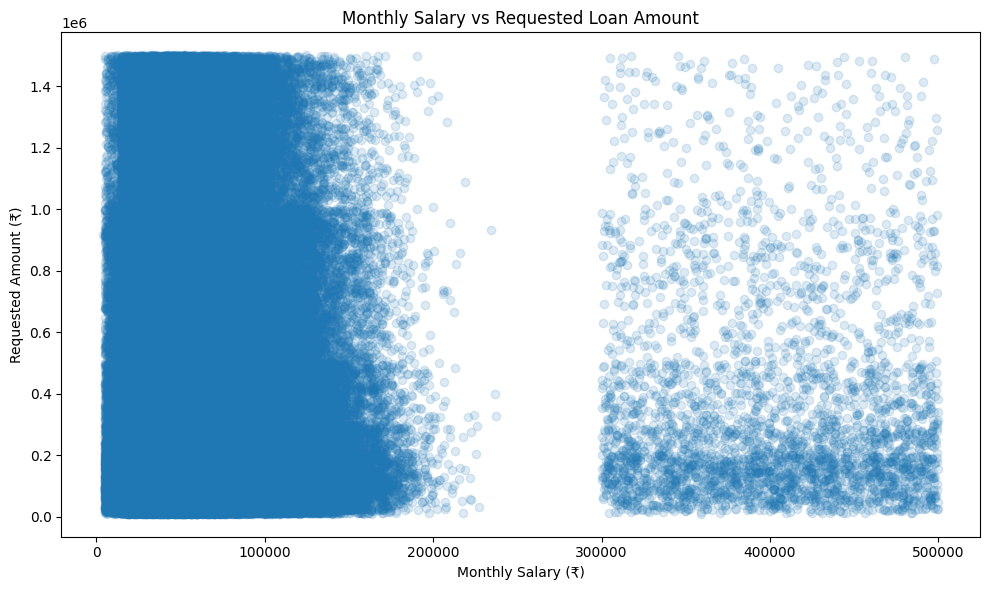

In [107]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["monthly_salary"],
    df["requested_amount"],
    alpha=0.15
)

plt.title("Monthly Salary vs Requested Loan Amount")
plt.xlabel("Monthly Salary (₹)")
plt.ylabel("Requested Amount (₹)")

plt.tight_layout()
plt.show()

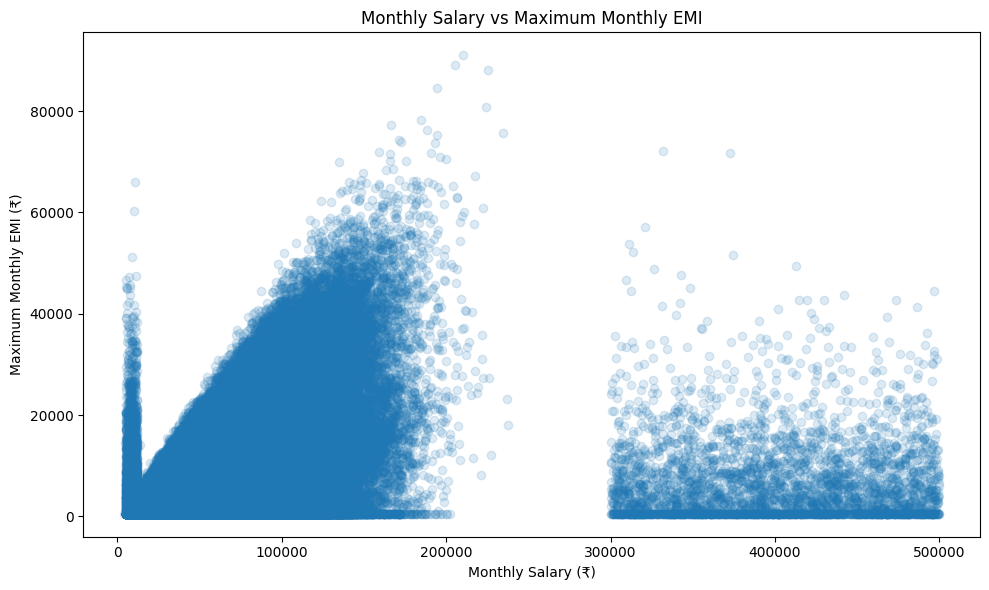

In [108]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["monthly_salary"],
    df["max_monthly_emi"],
    alpha=0.15
)

plt.title("Monthly Salary vs Maximum Monthly EMI")
plt.xlabel("Monthly Salary (₹)")
plt.ylabel("Maximum Monthly EMI (₹)")

plt.tight_layout()
plt.show()

In [109]:
EDA_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\data\processed\emi_prediction_dataset_eda.csv"
)

df.to_csv(EDA_PATH, index=False)

print("EDA dataset saved successfully!")
print("Location:", EDA_PATH)

EDA dataset saved successfully!
Location: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\data\processed\emi_prediction_dataset_eda.csv
